# 1. Environment Setup

In [47]:
# Import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import zscore

In [48]:
import os

print(os.getcwd())
print(os.listdir("../../data/raw"))

N:\-LEARNING\--Portfolio\time-series-forecasting-project\notebooks\week1
['holidays.csv', 'oil.csv', 'stores.csv', 'timeseries.csv']


In [49]:
plt.style.use("default")

In [50]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use("default")
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"
mpl.rcParams["text.color"] = "black"
mpl.rcParams["axes.labelcolor"] = "black"
mpl.rcParams["xtick.color"] = "black"
mpl.rcParams["ytick.color"] = "black"
mpl.rcParams["axes.edgecolor"] = "black"

# 2. Data Loading

In [51]:
# Import holidays dataset
df_holidays = pd.read_csv("../../data/raw/holidays.csv")
display(df_holidays.head())

,date,locale,locale_name,description
0,2012-03-02,Local,Manta,Fundacion de Manta
1,2012-04-01,Regional,Cotopaxi,Provincializacion de Cotopaxi
2,2012-04-12,Local,Cuenca,Fundacion de Cuenca
3,2012-04-14,Local,Libertad,Cantonizacion de Libertad
4,2012-04-21,Local,Riobamba,Cantonizacion de Riobamba


In [52]:
# Import oil dataset
df_oil = pd.read_csv("../../data/raw/oil.csv")
display(df_oil.head())

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [53]:
# Import stories dataset
df_stores = pd.read_csv("../../data/raw/stores.csv")
display(df_stores.head())

,store_nbr,city,region
0,1,Quito,Pichincha
1,2,Quito,Pichincha
2,3,Quito,Pichincha
3,4,Quito,Pichincha
4,5,Santo Domingo,Santo Domingo de los Tsachilas


In [54]:
# Import timeseries dataset
df_timeseries = pd.read_csv("../../data/raw/timeseries.csv")
display(df_timeseries.head())

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


# 3. Dataset Overview

In [55]:
# Check the size of each dataset
print("Holidays:", df_holidays.shape)
print("Stores:", df_stores.shape)
print("Oil:", df_oil.shape)
print("Time Series:", df_timeseries.shape)

Holidays: (350, 4)
Stores: (54, 3)
Oil: (1218, 2)
Time Series: (452, 2)


In [56]:
# Inspect column names in each dataset
print("Holidays columns:", df_holidays.columns.tolist())
print("Stores columns:", df_stores.columns.tolist())
print("Oil columns:", df_oil.columns.tolist())
print("Time Series columns:", df_timeseries.columns.tolist())

Holidays columns: ['date', 'locale', 'locale_name', 'description']
Stores columns: ['store_nbr', 'city', 'region']
Oil columns: ['date', 'dcoilwtico']
Time Series columns: ['date', 'unit_sales']


In [57]:
# Check data types in each dataset
print("Holidays dtypes:\n", df_holidays.dtypes, "\n")
print("Stores dtypes:\n", df_stores.dtypes, "\n")
print("Oil dtypes:\n", df_oil.dtypes, "\n")
print("Time Series dtypes:\n", df_timeseries.dtypes)

Holidays dtypes:
 date           str
locale         str
locale_name    str
description    str
dtype: object 

Stores dtypes:
 store_nbr    int64
city           str
region         str
dtype: object 

Oil dtypes:
 date              str
dcoilwtico    float64
dtype: object 

Time Series dtypes:
 date              str
unit_sales    float64
dtype: object


In [58]:
# Convert date columns to datetime
df_holidays["date"] = pd.to_datetime(df_holidays["date"])
df_oil["date"] = pd.to_datetime(df_oil["date"])
df_timeseries["date"] = pd.to_datetime(df_timeseries["date"])

In [59]:
# Verify datetime conversion
print("Holidays date dtype:", df_holidays["date"].dtype)
print("Oil date dtype:", df_oil["date"].dtype)
print("Time Series date dtype:", df_timeseries["date"].dtype)

Holidays date dtype: datetime64[us]
Oil date dtype: datetime64[us]
Time Series date dtype: datetime64[us]


In [60]:
# Inspect summary statistics for key numeric columns
display(df_timeseries.describe())
display(df_oil.describe())

,date,unit_sales
count,452,452.000000
mean,2013-08-15 21:46:11.681416,480.090708
min,2013-01-02 00:00:00,4.000000
25%,2013-04-24 18:00:00,358.000000
50%,2013-08-15 12:00:00,445.500000
75%,2013-12-06 06:00:00,578.250000
max,2014-03-31 00:00:00,1203.000000
std,NaN,170.839776


,date,dcoilwtico
count,1218,1175.000000
mean,2015-05-02 12:00:00,67.714366
min,2013-01-01 00:00:00,26.190000
25%,2014-03-03 06:00:00,46.405000
50%,2015-05-02 12:00:00,53.190000
75%,2016-06-30 18:00:00,95.660000
max,2017-08-31 00:00:00,110.620000
std,NaN,25.630476


In [61]:
# Check date ranges for the main time-based datasets
print("Time series date range:", df_timeseries["date"].min(), "to", df_timeseries["date"].max())
print("Oil date range:", df_oil["date"].min(), "to", df_oil["date"].max())
print("Holidays date range:", df_holidays["date"].min(), "to", df_holidays["date"].max())

Time series date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00
Oil date range: 2013-01-01 00:00:00 to 2017-08-31 00:00:00
Holidays date range: 2012-03-02 00:00:00 to 2017-12-26 00:00:00


# 4. Initial Time Series Inspection

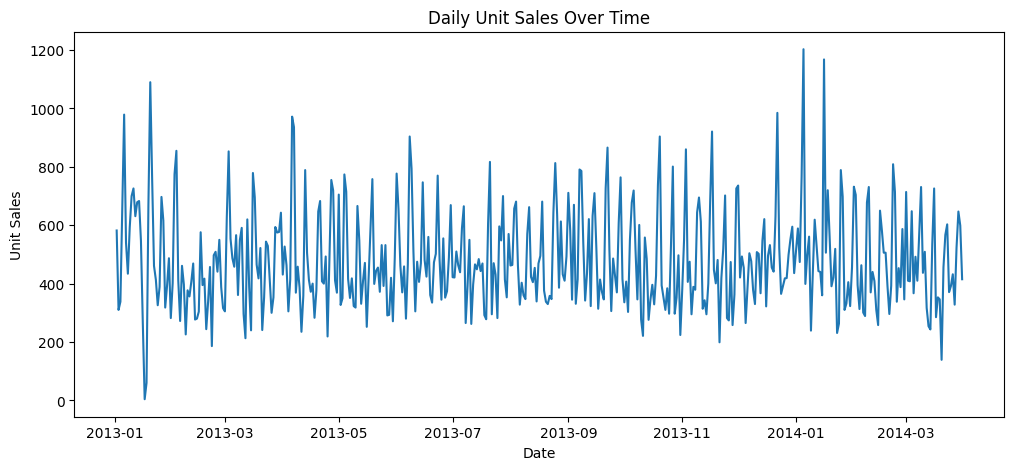

In [62]:
# Plot the main time series
plt.figure(figsize=(12, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"])
plt.title("Daily Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

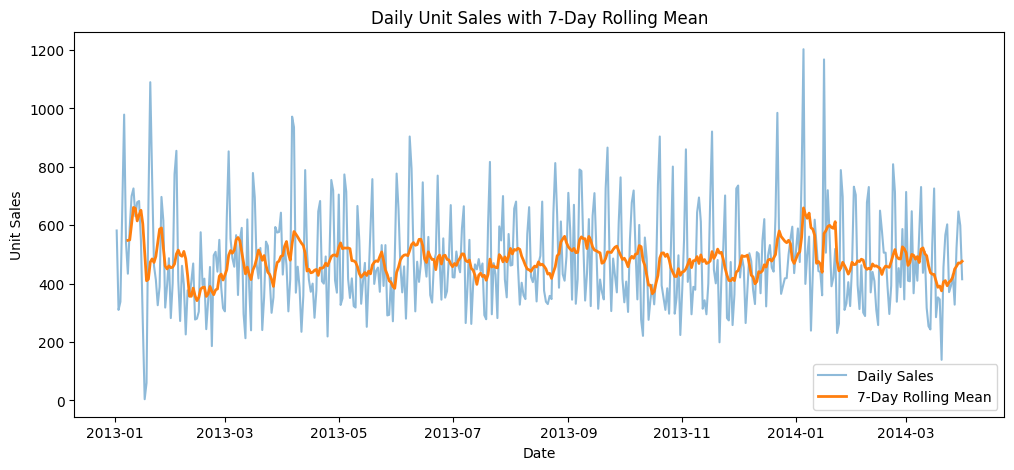

In [63]:
# Plot the time series with a 7-day rolling mean
df_timeseries["rolling_mean_7"] = df_timeseries["unit_sales"].rolling(window=7).mean()

plt.figure(figsize=(12, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"], alpha=0.5, label="Daily Sales")
plt.plot(df_timeseries["date"], df_timeseries["rolling_mean_7"], linewidth=2, label="7-Day Rolling Mean")
plt.title("Daily Unit Sales with 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

The daily sales series is highly volatile, with frequent short-term fluctuations and several visible spikes. The 7-day rolling mean smooths the daily noise and suggests that the average sales level remains relatively stable over time, with only moderate local changes. At this stage, there is no strong long-term upward or downward trend, but several unusual peaks should be examined more closely.

# 5. Distribution of Unit Sales

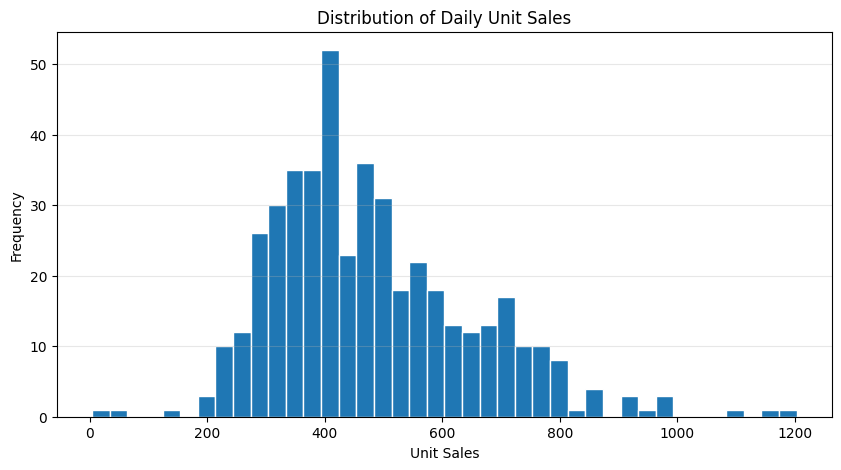

In [64]:
# Plot a clearer distribution of daily unit sales
plt.figure(figsize=(10, 5))
plt.hist(df_timeseries["unit_sales"], bins=40, edgecolor="white")
plt.title("Distribution of Daily Unit Sales")
plt.xlabel("Unit Sales")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

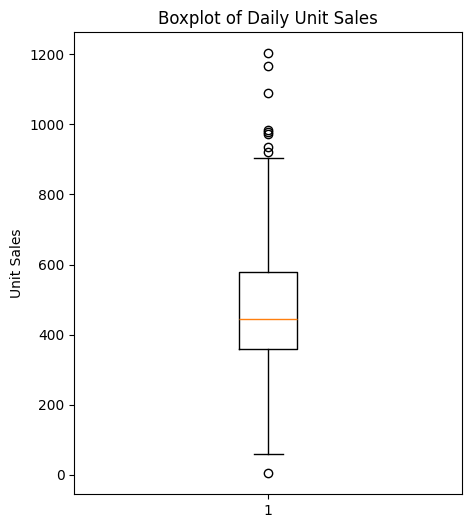

In [65]:
# Plot a vertical boxplot to inspect potential outliers
plt.figure(figsize=(5, 6))
plt.boxplot(df_timeseries["unit_sales"])
plt.title("Boxplot of Daily Unit Sales")
plt.ylabel("Unit Sales")
plt.show()

The distribution of daily unit sales is positively skewed, with most observations concentrated in the mid-range and a smaller number of unusually high values. The boxplot confirms the presence of several potential upper outliers, as well as at least one very low value near zero. These observations should be reviewed further before deciding whether they represent data issues or valid business events.

# 6. Missing Values Analysis

In [66]:
# Check missing values in each dataset
print("Holidays missing values:\n", df_holidays.isna().sum(), "\n")
print("Stores missing values:\n", df_stores.isna().sum(), "\n")
print("Oil missing values:\n", df_oil.isna().sum(), "\n")
print("Time Series missing values:\n", df_timeseries.isna().sum())

Holidays missing values:
 date           0
locale         0
locale_name    0
description    0
dtype: int64 

Stores missing values:
 store_nbr    0
city         0
region       0
dtype: int64 

Oil missing values:
 date           0
dcoilwtico    43
dtype: int64 

Time Series missing values:
 date              0
unit_sales        0
rolling_mean_7    6
dtype: int64


The main time series does not contain missing values in the `date` or `unit_sales` columns, which is a good starting point for further analysis. The oil dataset contains 43 missing values in the oil price column, which may require treatment if this table is later used for additional analysis or merging. The missing values in `rolling_mean_7` are expected because a 7-day rolling average cannot be calculated for the first six observations.

# 7 Oil Price Missing Values

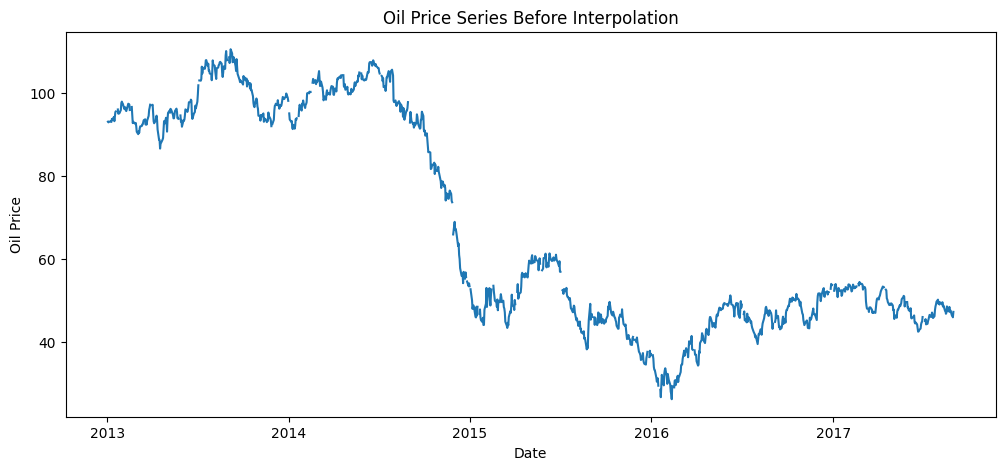

In [67]:
# Plot the oil price series before handling missing values
plt.figure(figsize=(12, 5))
plt.plot(df_oil["date"], df_oil["dcoilwtico"])
plt.title("Oil Price Series Before Interpolation")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.show()

In [68]:
# Fill missing oil prices using linear interpolation
df_oil["oil_price_interpolated"] = df_oil["dcoilwtico"].interpolate(method="linear")

In [69]:
# Check missing values after interpolation
print(df_oil[["dcoilwtico", "oil_price_interpolated"]].isna().sum())

dcoilwtico                43
oil_price_interpolated     1
dtype: int64


In [70]:
# Find rows where the interpolated oil price is still missing
df_oil[df_oil["oil_price_interpolated"].isna()]

,date,dcoilwtico,oil_price_interpolated
0,2013-01-01,NaN,NaN


In [71]:
# Fill the remaining missing value at the start of the series
df_oil["oil_price_interpolated"] = df_oil["oil_price_interpolated"].bfill()

In [72]:
print(df_oil[["dcoilwtico", "oil_price_interpolated"]].isna().sum())

dcoilwtico                43
oil_price_interpolated     0
dtype: int64


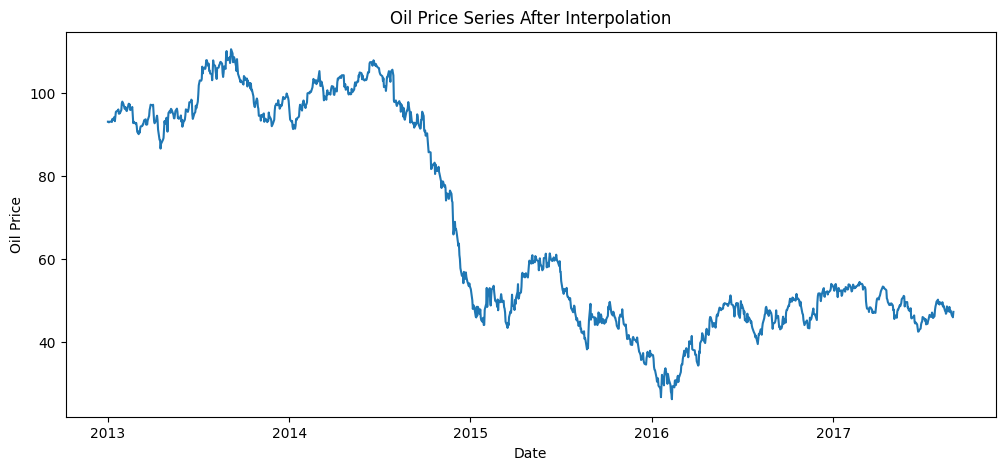

In [73]:
# Plot the oil price series after interpolation
plt.figure(figsize=(12, 5))
plt.plot(df_oil["date"], df_oil["oil_price_interpolated"])
plt.title("Oil Price Series After Interpolation")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.show()

The oil dataset initially contained missing values in the `dcoilwtico` column. These were handled by applying linear interpolation and then backfilling the first remaining missing observation at the start of the series. The resulting `oil_price_interpolated` column contains no missing values and provides a continuous supporting time series for further analysis if needed.

In [74]:
# Save the oil dataset with the interpolated price column
df_oil.to_csv("../../data/processed/oil_interpolated.csv", index=False)

# 8. Seasonal Decomposition

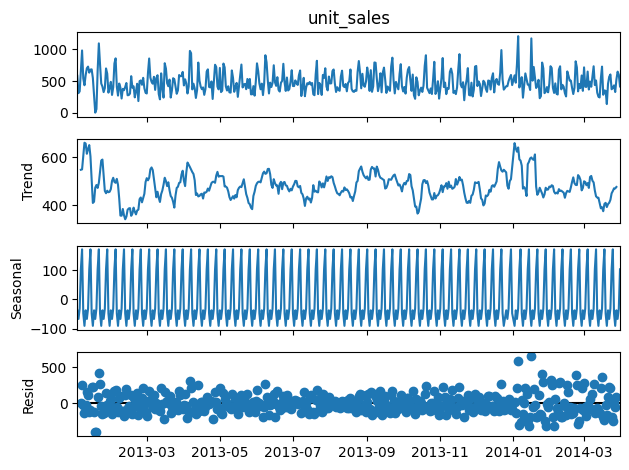

In [75]:
# Prepare the time series for seasonal decomposition
ts = df_timeseries.copy()
ts = ts.sort_values("date")
ts = ts.set_index("date")

decomposition = seasonal_decompose(ts["unit_sales"], model="additive", period=7)
decomposition.plot()
plt.show()

The seasonal decomposition suggests that the time series contains a clear repeating weekly pattern, which supports the choice of a 7-day seasonal period. The trend component shows moderate local changes over time, but no strong long-term upward or downward movement. The residual component still contains substantial variation, indicating that not all fluctuations are explained by trend and weekly seasonality alone.

# 9. Stationarity Analysis

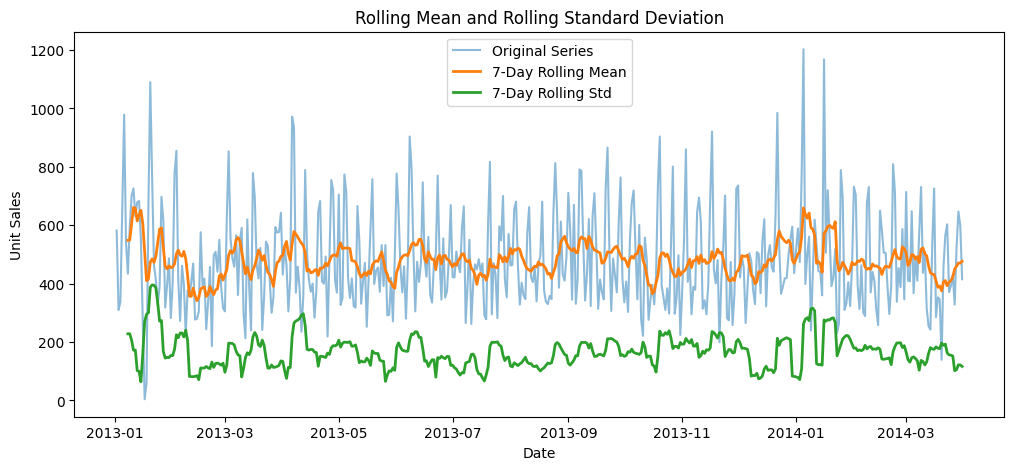

In [76]:
# Plot rolling mean and rolling standard deviation
rolling_mean = df_timeseries["unit_sales"].rolling(window=7).mean()
rolling_std = df_timeseries["unit_sales"].rolling(window=7).std()

plt.figure(figsize=(12, 5))
plt.plot(df_timeseries["date"], df_timeseries["unit_sales"], label="Original Series", alpha=0.5)
plt.plot(df_timeseries["date"], rolling_mean, label="7-Day Rolling Mean", linewidth=2)
plt.plot(df_timeseries["date"], rolling_std, label="7-Day Rolling Std", linewidth=2)
plt.title("Rolling Mean and Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

In [77]:
# Perform the Augmented Dickey-Fuller test
adf_result = adfuller(df_timeseries["unit_sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -5.092260058040776
p-value: 1.453017741687818e-05
Critical Values:
   1%: -3.445542818501549
   5%: -2.868238133603207
   10%: -2.5703378690483176


The rolling mean and rolling standard deviation show some variation over time, so the series does not appear perfectly stable from a visual perspective. However, the Augmented Dickey-Fuller test returns a very small p-value and an ADF statistic lower than all critical values, which suggests that the time series can be considered stationary in statistical terms.

# 10. Autocorrelation Analysis

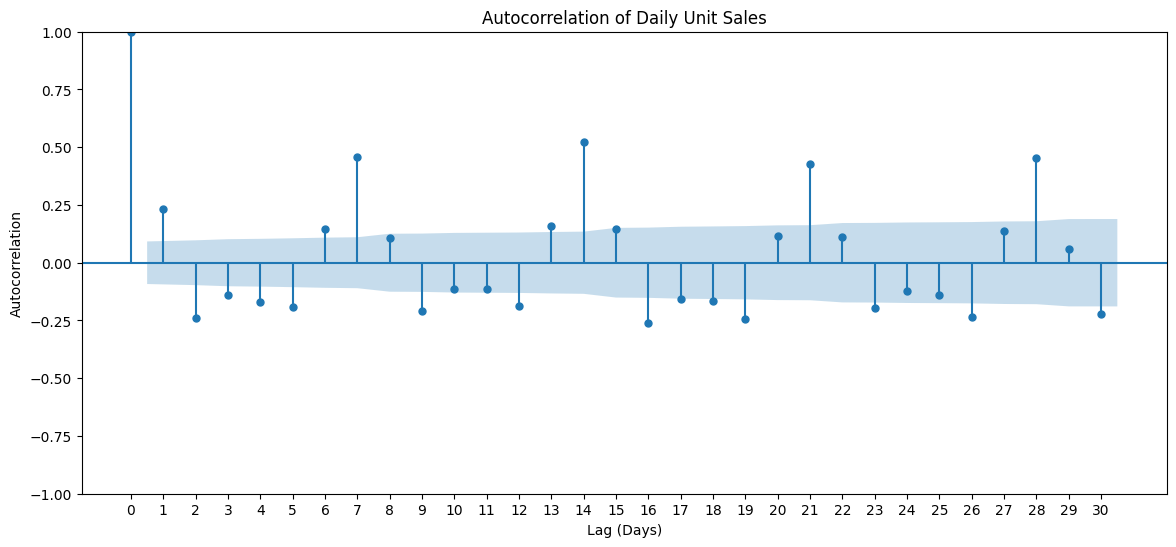

In [78]:
# Plot autocorrelation for the main time series
fig, ax = plt.subplots(figsize=(14, 6))
plot_acf(df_timeseries["unit_sales"], lags=30, ax=ax)

ax.set_title("Autocorrelation of Daily Unit Sales")
ax.set_xlabel("Lag (Days)")
ax.set_ylabel("Autocorrelation")
ax.set_xticks(range(0, 31, 1))

plt.show()

The autocorrelation plot shows statistically significant spikes at lags 7, 14, 21, and 28, which suggests a clear weekly seasonal pattern in the sales series. There is also some short-term dependence at lower lags, but the repeating 7-day structure is the most prominent feature. This result is consistent with the earlier seasonal decomposition.

# 11. Reviewing Extreme Values

In [79]:
# Review the lowest and highest sales values
display(df_timeseries[["date", "unit_sales"]].nsmallest(5, "unit_sales"))
display(df_timeseries[["date", "unit_sales"]].nlargest(5, "unit_sales"))

,date,unit_sales
15,2013-01-17,4.0
16,2013-01-18,60.0
440,2014-03-20,139.0
51,2013-02-22,186.0
323,2013-11-21,199.0


,date,unit_sales
366,2014-01-05,1203.0
377,2014-01-16,1168.0
18,2013-01-20,1090.0
354,2013-12-22,985.0
4,2013-01-06,979.0


In [82]:
# Calculate z-scores for unit sales
df_timeseries["unit_sales_zscore"] = zscore(df_timeseries["unit_sales"])

# Show observations with |z-score| > 3
display(df_timeseries.loc[df_timeseries["unit_sales_zscore"].abs() > 3, ["date", "unit_sales", "unit_sales_zscore"]])

,date,unit_sales,unit_sales_zscore
18,2013-01-20,1090.0,3.574022
366,2014-01-05,1203.0,4.236193
377,2014-01-16,1168.0,4.031096


The extreme value review suggests that the sales series contains both unusually low and unusually high observations. The lowest observed value is 4, while the z-score analysis identifies three sales values with an absolute z-score above 3, confirming that a small number of observations are statistically extreme. These findings are consistent with the histogram and boxplot, which also indicated the presence of upper outliers. However, all extreme values will be kept in the dataset, since there is not enough evidence to classify them as data errors rather than valid business events.

# 12. Cleaning Decisions

The cleaning process for the main time series was intentionally minimal. The `date` column was converted to a proper datetime format, and the dataset was reviewed for missing values and unusual observations. No sales values were removed or imputed, since the main series contained no missing values and there was not enough evidence to classify the extreme values as data errors. The helper column `rolling_mean_7`, created only for exploratory analysis, was excluded from the final cleaned dataset.

# 13. Final Cleaned Dataset

In [80]:
# Create the final cleaned dataset
timeseries_cleaned = df_timeseries[["date", "unit_sales"]].copy()

# Save the cleaned time series
timeseries_cleaned.to_csv("../../data/timeseries_cleaned.csv", index=False)

In [81]:
# Reload the cleaned dataset and parse the date column
df_timeseries_cleaned = pd.read_csv("../../data/timeseries_cleaned.csv", parse_dates=["date"])

display(df_timeseries_cleaned.head())
df_timeseries_cleaned.info()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        452 non-null    datetime64[us]
 1   unit_sales  452 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 7.2 KB
